<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [57]:
# Importation de la librairie pandas
import  pandas as pd

# Importation de la librairie numpy

import numpy as np

# Importation de la librairie plotly express
import plotly.express as px

# Importation de matplotlib

import matplotlib.pyplot as plt

# Importation de plotly.express
import plotly.express as px


In [58]:
# Instruction permettant de paramettrer l'affichage de toutes les colonnes d'un dataframe
# l'option none signifie qu'il n'y a aucune limite sur le nombre de colonne
pd.set_option('display.max_columns', None)



<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [60]:
# Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")


# Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")


# Importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")


C:\Users\Fujitsu\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\Fujitsu\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():
C:\Users\Fujitsu\anaconda3\Lib\site-packages\openpyxl\worksheet\_read_only.py:85: UserWarning: Unknown extension is not supported and will be removed
  for idx, row in parser.parse():


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Caractéristiques des différentes variables et identification des érreurs</h4>
</div>

In [67]:
# Afficher les dimensions du dataset

print("La table comporte {} observation(s) ou article(s)".format(df_erp.shape[0]),  end =" ")
print("et {} colonne(s)".format(df_erp.shape[1]))

La table comporte 825 observation(s) ou article(s) et 6 colonne(s)


In [68]:
# Affichage des caractéristiques des colonnes

df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


il n'y a aucune variable avec des données manquantes 

In [70]:
# Affichage des 5 1ere lignes de la table

df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [71]:
# Vérifier s'il y a des lignes en double dans la colonne product_id

df_erp.loc[df_erp["product_id"].duplicated(keep=False), :]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [72]:
# Afficher les valeurs distinctes de la colonne product_id pour vérifier s'il existe des id au mauvais format

print(df_erp["product_id"].unique().tolist())


[3847, 3849, 3850, 4032, 4039, 4040, 4041, 4042, 4043, 4045, 4046, 4047, 4048, 4049, 4050, 4051, 4052, 4053, 4054, 4055, 4056, 4057, 4058, 4059, 4060, 4062, 4063, 4064, 4065, 4066, 4067, 4068, 4069, 4070, 4071, 4072, 4073, 4074, 4075, 4076, 4077, 4078, 4079, 4081, 4083, 4084, 4085, 4086, 4087, 4090, 4092, 4094, 4095, 4096, 4097, 4098, 4099, 4100, 4101, 4102, 4103, 4104, 4105, 4106, 4107, 4108, 4115, 4130, 4132, 4137, 4138, 4139, 4141, 4142, 4144, 4146, 4147, 4148, 4149, 4150, 4151, 4152, 4153, 4154, 4155, 4156, 4157, 4158, 4159, 4160, 4161, 4162, 4163, 4164, 4165, 4166, 4167, 4168, 4170, 4171, 4172, 4173, 4174, 4176, 4177, 4178, 4179, 4180, 4181, 4182, 4183, 4186, 4187, 4188, 4190, 4191, 4192, 4193, 4194, 4195, 4196, 4197, 4198, 4200, 4201, 4202, 4203, 4204, 4205, 4207, 4208, 4209, 4210, 4211, 4212, 4213, 4215, 4216, 4217, 4219, 4220, 4221, 4222, 4223, 4224, 4225, 4227, 4228, 4229, 4231, 4232, 4233, 4235, 4239, 4240, 4241, 4242, 4244, 4245, 4246, 4248, 4250, 4251, 4253, 4254, 4256, 425

In [73]:
# Afficher les valeurs distinctes de la colonne stock_status

df_erp["stock_status"].unique().tolist()


['instock', 'outofstock']

In [74]:
# la variable stock_status est liée à la variable stock_quantity

df_erp.loc[df_erp["stock_status"] == "outofstock", :].sort_values("stock_quantity").head(10)

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
449,4973,0,10.0,-10,outofstock,4.96
573,5700,1,44.5,-1,outofstock,22.30
2,3850,1,20.8,0,outofstock,10.64
531,5544,1,61.6,0,outofstock,31.51
523,5505,0,10.1,0,outofstock,5.22
519,5487,1,43.5,0,outofstock,23.37
494,5384,1,28.8,0,outofstock,15.18
487,5075,1,43.3,0,outofstock,21.70
486,5070,1,84.7,0,outofstock,47.43
473,5021,0,17.1,0,outofstock,8.92


In [75]:
# Création d'une colonne "stock_status_2"
# La valeur de cette deuxième colonne sera fonction de la valeur de la colonne "stock_quantity"
# Si la valeur de la colonne "stock_quantity" est nulle, renseigner "outofstock" sinon mettre "instock"



df_erp["stock_status_2"] = "NA"

df_erp.loc[df_erp["stock_quantity"] == 0 , "stock_status_2"] =  "outofstock"

df_erp.loc[df_erp["stock_quantity"] != 0 , "stock_status_2"] =  "instock"

In [76]:
# Vérifions que les colonnes stock_status et stock_status_2 sont identiques 


verif_erp = df_erp["stock_status"] == df_erp["stock_status_2"]
verif_erp = verif_erp.reset_index(name="var_identique")

# identification des lignes pour lesquelles les deux variables sont différentes

verif_erp.loc[verif_erp["var_identique"] == False, :]

,index,var_identique
4,4,False
398,398,False
449,449,False
573,573,False


In [77]:
# Affichage des lignes qui contiennent des érreurs pour la colonne stock_quantity 

df_erp.iloc[[4,398, 449, 573], : ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock
449,4973,0,10.0,-10,outofstock,4.96,instock
573,5700,1,44.5,-1,outofstock,22.30,instock


On observe la présence de **données aberrantes** sur la variable stock quantité. Elle contient des valeurs négatives: -10 et -1.
Nous allons remplacer ces valeurs négatives par 0 car la variable stock_status associée est **outofstock** traduisant 
donc la rupture de stock du produit. 

In [79]:
# Correction des incohérences


# remplacement des valeurs de valariable stock_quantity des observations 449 et 573  par 0 


df_erp.loc[[449, 573], "stock_quantity"] = 0

# Création de la variable stock_status_corrige tennant compte des outliers corrigés

df_erp["stock_status_corrige"] = "NA"


df_erp.loc[df_erp["stock_quantity"] == 0 , "stock_status_corrige"] =  "outofstock"

df_erp.loc[df_erp["stock_quantity"] != 0 , "stock_status_corrige"] =  "instock"

In [80]:
# Vérification de la correction des érreurs

# Affichage des observations problématiques corrigées
df_erp.iloc[[4,398, 449, 573], : ]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,stock_status_corrige
4,4039,1,46.0,3,outofstock,23.77,instock,instock
398,4885,1,18.7,0,instock,9.66,outofstock,outofstock
449,4973,0,10.0,0,outofstock,4.96,instock,outofstock
573,5700,1,44.5,0,outofstock,22.30,instock,outofstock


In [81]:
# Affichage de la nouvelle table

df_erp.sort_values("stock_quantity").head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2,stock_status_corrige
326,4706,1,16.8,0,outofstock,8.68,outofstock,outofstock
188,4283,1,27.0,0,outofstock,13.25,outofstock,outofstock
185,4279,0,10.8,0,outofstock,5.64,outofstock,outofstock
184,4278,0,21.5,0,outofstock,10.78,outofstock,outofstock
180,4274,1,12.9,0,outofstock,6.33,outofstock,outofstock


In [82]:
# Sauvergarde des données au format csv

df_erp["stock_status"] = df_erp["stock_status_corrige"]

df_erp = df_erp[["product_id", "onsale_web", "price", "stock_quantity", "stock_status", "purchase_price"]].copy() 

df_erp.to_csv("df_erp.csv", index=False)


In [83]:
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,instock,23.77
...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48
821,7204,0,45.0,9,instock,24.18
822,7247,1,54.8,6,instock,27.18
823,7329,0,26.5,14,instock,13.42


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.2 - Analyse exploratoire de la variable PRIX</h4>
</div>

In [85]:
# Vérifions s'il existe une anomalie sur les prix : prix nul, negatif ou non renseigné


print("Nombre d'articles avec un prix non renseigné: {}".format(df_erp.loc[df_erp["price"].isnull(), :].shape[0]))

print("Nombre d'articles avec un prix nul: {}".format(df_erp.loc[df_erp["price"] == 0, :].shape[0]))

print("Nombre d'articles avec un prix négatif: {}".format(df_erp.loc[df_erp["price"] < 0 , :].shape[0]))


Nombre d'articles avec un prix non renseigné: 0
Nombre d'articles avec un prix nul: 0
Nombre d'articles avec un prix négatif: 3


In [86]:
# Affichage du prix maximum et minimum

print("Le prix maximum est :", df_erp["price"].max(), "et le prix minimum est :", df_erp["price"].min())


# ou df_erp["price"].describe() 

Le prix maximum est : 225.0 et le prix minimum est : -20.0


Trois articles ont des prix négatifs. Nous avons adopté deux approches pour remplacer ces prix négatifs. La première consiste à remplacer les prix négatifs par le prix moyen de tous les articles. Pour la deuxieme approche, les prix négatifs sont remplacés par un nouveau prix calculé en fonction du prix d'achat. Premierement le pourcentage d'augmentation du prix d'achat pour obtenir le prix de vente de chaque article a été determiné. Les nouveaux prix ( de remplacement des prix négatifs) sont déterminé en appliquant le pourcentage d'augmentation moyen des prix d'achats (entre le prix d'achat et le prix de vente ) au prix d'achat des produits avec des prix de vente négatifs.

In [88]:

# 1ere approche

# Création d'une variable prix_vente et remplacement des prix négatifs par une valeur manquantes 

df_erp["prix_vente"] = df_erp["price"]

df_erp.loc[df_erp["prix_vente"] < 0 , "prix_vente"] = np.NaN

# Remplacement des valeurs maquantes de la colonnes price_2 par le prix moyen

df_erp.loc[df_erp["prix_vente"].isnull() , "prix_vente"] = df_erp["prix_vente"].mean()


In [89]:
# Vérification du remplacement 

df_erp.loc[df_erp["price"] < 0 , ["price", "prix_vente"]]


,price,prix_vente
151,-20.0,32.350304
469,-8.0,32.350304
739,-9.1,32.350304


In [90]:

# 2e approche

# Vérifions s'il existe une anomalie sur les prix d'achat : prix nul, negatif ou non renseigné

print("Nombre d'articles avec un prix non renseigné: {}".format(df_erp.loc[df_erp["purchase_price"].isnull(), :].shape[0]))

print("Nombre d'articles avec un prix nul: {}".format(df_erp.loc[df_erp["purchase_price"] == 0, :].shape[0]))

print("Nombre d'articles avec un prix négatif: {}".format(df_erp.loc[df_erp["purchase_price"] < 0 , :].shape[0]))


Nombre d'articles avec un prix non renseigné: 0
Nombre d'articles avec un prix nul: 0
Nombre d'articles avec un prix négatif: 0


In [91]:

# Création d'une variable price_vente_2 et remplacement des prix négatifs par une valeur manquantes 

df_erp["prix_vente_2"] = df_erp["price"]

df_erp.loc[df_erp["prix_vente_2"] < 0 , "prix_vente_2"] = np.NaN

# Calcul du pourcentage d'augmentation du prix d'achat popur obtenir le prix de vente, pour chaque produit

df_erp["augm_prix"] = (df_erp["prix_vente_2"] - df_erp["purchase_price"]) / df_erp["purchase_price"]


# Remplacement des valeurs maquantes de la colonnes price_vente_2  par le prix d'achat * l'augmentation moyen des prix d'achat 

df_erp.loc[df_erp["prix_vente_2"].isnull() , "prix_vente_2"] = round(df_erp["purchase_price"] * (1 + df_erp["augm_prix"].mean()), 1)

In [92]:
# Vérification du remplacement

df_erp.loc[df_erp["price"] < 0 , ["price", "prix_vente", "prix_vente_2", "augm_prix"]]

,price,prix_vente,prix_vente_2,augm_prix
151,-20.0,32.350304,19.9,NaN
469,-8.0,32.350304,8.4,NaN
739,-9.1,32.350304,8.9,NaN


In [93]:

# Le remplacement des prix négatif avec la 2e approche est retenue 

df_erp = df_erp[["product_id", "onsale_web", "price", "stock_quantity", "stock_status", "purchase_price", "prix_vente_2", "augm_prix"]].copy()

df_erp.rename(columns = {"prix_vente_2":"prix_vente"}, inplace=True)

df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix
0,3847,1,24.2,16,instock,12.88,24.2,0.878882
1,3849,1,34.3,10,instock,17.54,34.3,0.955530
2,3850,1,20.8,0,outofstock,10.64,20.8,0.954887
3,4032,1,14.1,26,instock,6.92,14.1,1.037572
4,4039,1,46.0,3,instock,23.77,46.0,0.935212
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,45.0,0.916525
821,7204,0,45.0,9,instock,24.18,45.0,0.861042
822,7247,1,54.8,6,instock,27.18,54.8,1.016188
823,7329,0,26.5,14,instock,13.42,26.5,0.974665


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.3 - Analyse exploratoire de la variable STOCK</h4>
</div>

In [95]:
# Vérifions s'il existe une anomalie sur le stock des quantités : negatif ou non renseigné

print("Nombre d'articles avec le stock de quantité non renseigné: {}".format(df_erp.loc[df_erp["stock_quantity"].isnull(), :].shape[0]))

print("Nombre d'articles avec le stock de quantité négatif: {}".format(df_erp.loc[df_erp["stock_quantity"] < 0 , :].shape[0]))

Nombre d'articles avec le stock de quantité non renseigné: 0
Nombre d'articles avec le stock de quantité négatif: 0


In [96]:
# Affichage le stock de quanité maximum et minimum

print("Le stock de quantité maximum est :", df_erp["stock_quantity"].max(), "et le stock de quantité minimum est :", df_erp["stock_quantity"].min())


Le stock de quantité maximum est : 145 et le stock de quantité minimum est : 0


In [97]:
# Ou
df_erp["stock_quantity"].describe() 

count    825.000000
mean      21.602424
std       21.917863
min        0.000000
25%        7.000000
50%       18.000000
75%       30.000000
max      145.000000
Name: stock_quantity, dtype: float64

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.4 - Analyse exploratoire de la variable ONSALE_WEB</h4>
</div>

In [99]:
# verification s'il existe des données manquantes 

print("Nombre d'observations avec la variable onsale_web manquantes: {}".format(df_erp.loc[df_erp["onsale_web"].isnull(), :].shape[0]))

Nombre d'observations avec la variable onsale_web manquantes: 0


In [100]:
# Identification des modalités de la variable onsale_web 

df_erp["onsale_web"].unique().tolist()

# la variable onsale_web contient deux modalités 0 et 1 et indique si le produit est en promotion ou pas.
# avec 0 = le produit n'est pas en promotion et 1 = le produit est en promotion./ en vente  

[1, 0]

In [101]:
df_erp

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix
0,3847,1,24.2,16,instock,12.88,24.2,0.878882
1,3849,1,34.3,10,instock,17.54,34.3,0.955530
2,3850,1,20.8,0,outofstock,10.64,20.8,0.954887
3,4032,1,14.1,26,instock,6.92,14.1,1.037572
4,4039,1,46.0,3,instock,23.77,46.0,0.935212
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,45.0,0.916525
821,7204,0,45.0,9,instock,24.18,45.0,0.861042
822,7247,1,54.8,6,instock,27.18,54.8,1.016188
823,7329,0,26.5,14,instock,13.42,26.5,0.974665


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.5 - Analyse exploratoire de la variable prix d'achat</h4>
</div>

In [103]:
# Vérifions s'il existe une anomalie sur le prix d'achat. la colonne purchase_price: prix nul, negatif ou non renseigné

print("Nombre d'articles avec un prix d'achat non renseigné: {}".format(df_erp.loc[df_erp["purchase_price"].isnull(), :].shape[0]))

print("Nombre d'articles avec un prix d'achat nul: {}".format(df_erp.loc[df_erp["purchase_price"] == 0, :].shape[0]))

print("Nombre d'articles avec un prix  d'achat négatif: {}".format(df_erp.loc[df_erp["purchase_price"] < 0 , :].shape[0]))

Nombre d'articles avec un prix d'achat non renseigné: 0
Nombre d'articles avec un prix d'achat nul: 0
Nombre d'articles avec un prix  d'achat négatif: 0


In [104]:
# Affichage du maximum et du minimum de la variable purchase_price 

print("Le prix d'achat maximum est :", df_erp["purchase_price"].max(), "et le prix d'achat minimum est :", df_erp["purchase_price"].min())




df_erp["augm_prix"] = round(df_erp["augm_prix"] * 100, 2)

#Sauvegarde de la table

df_erp.to_csv("df_erp.csv", index=False)

Le prix d'achat maximum est : 137.81 et le prix d'achat minimum est : 2.74


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [106]:
print("Le fichier web.xlsx contient", df_web.shape[0] , "observations  et", df_web.shape[1] , "variables")

Le fichier web.xlsx contient 1513 observations  et 29 variables


In [107]:
# Description des colonnes 

df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [108]:
# Affichage des modalités de chaque variable

# Création d'une liste contenant les différentes variables

liste_variables = df_web.columns.tolist()

#for var in liste_variables:
#    print("Modalités de la variable", var, " :", df_web[var].unique().tolist())


In [109]:
# Selection des colonnes à conserver

#df_web = df_web[["sku", "total_sales",  "post_date", "post_date_gmt", "product_type", "post_name", "post_modified_gmt", "post_modified",  "post_type"]]

df_web_2 = df_web[["sku", "total_sales",  "post_date", "product_type", "post_name", "post_modified", "post_type"]]

In [110]:
# Définition de la liste des valeur sku 
list_unique_sku = df_web_2["sku"].unique().tolist()

# Création d'un df de la liste des valeurs unique sku
df_unique_sku = pd.DataFrame(list_unique_sku, columns=["sku_value"])

df_unique_sku["length_sku"] = df_unique_sku["sku_value"].astype(str).str.len()


In [111]:
# Valeurs de la variable sku qui ne respectent pas la bonne codification (erreur de formatage)
# c'est à dire que la taille de la variable sku contient +/- de 5 caracteres 

erreur_formatage_sku = df_unique_sku.loc[df_unique_sku["length_sku"] != 5, "sku_value"].tolist()

print(erreur_formatage_sku)

[nan, 9636, 804, 3506, 9937, 802, 4679, 3509, 2534, 791, 793, '13127-1', 304, 7033, 3568, 7086, 805, 7819, 2179, 38, 8463, 9562, 531, 2361, 1366, 812, 3383, 3510, 8365, 3507, 1364, 8193, 798, 1662, 7032, 5646, 8344, 1360, 'bon-cadeau-25-euros', 523, 41, 807, 7818, 6616]


In [112]:

# Affichage des caractéristiques des articles dont le format de la variable sku n'est pas respectée


#df_erreur_form = df_unique_sku.loc[df_unique_sku["length_sku"] != 5, :].reset_index()

mask = df_web_2["sku"].isin(erreur_formatage_sku)

df_web_2.loc[mask, :]

,sku,total_sales,post_date,product_type,post_name,post_modified,post_type
8,NaN,NaN,NaT,NaN,NaN,NaT,NaN
20,NaN,NaN,NaT,NaN,NaN,NaT,NaN
30,NaN,NaN,NaT,NaN,NaN,NaT,NaN
33,9636,0.0,2018-03-22 10:44:57,Whisky,whisky-wemyss-the-hive-12-ans,2020-08-19 17:45:03,product
37,NaN,NaN,NaT,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...
1445,NaN,NaN,NaT,NaN,NaN,NaT,NaN
1453,2534,4.0,2018-04-14 11:50:29,Vin,marcel-windholtz-eau-de-vie-de-fraise,2020-08-21 15:45:04,attachment
1457,NaN,NaN,NaT,NaN,NaN,NaT,NaN
1462,798,8.0,2018-04-14 12:05:09,Vin,marcel-windholtz-eau-de-vie-de-kirsch-dalsace-...,2020-07-23 10:15:03,product


In [113]:
# Affichage des lignes sans code article

df_web_2.loc[df_web_2["sku"].isnull(), :]

,sku,total_sales,post_date,product_type,post_name,post_modified,post_type
8,NaN,NaN,NaT,NaN,NaN,NaT,NaN
20,NaN,NaN,NaT,NaN,NaN,NaT,NaN
30,NaN,NaN,NaT,NaN,NaN,NaT,NaN
37,NaN,NaN,NaT,NaN,NaN,NaT,NaN
41,NaN,NaN,NaT,NaN,NaN,NaT,NaN
...,...,...,...,...,...,...,...
1384,NaN,NaN,NaT,NaN,NaN,NaT,NaN
1429,NaN,NaN,NaT,NaN,NaN,NaT,NaN
1432,NaN,NaN,NaT,NaN,NaN,NaT,NaN
1445,NaN,NaN,NaT,NaN,NaN,NaT,NaN


In [114]:
# Création de la table ayant les code articles identifiés

mask_2 = ~df_web_2["sku"].isnull()

df_web_not_NA = df_web_2.loc[mask_2, :]

In [115]:
# Vérification s'il existe des doublons

# Création d'une fonction pour compter le nombre de valeur en double de la variable sku

def check_duplicate(dataframe: pd.DataFrame, variable) -> pd.Series:
    """
    Identifies and counts duplicate SKU values in the dataframe.
    
    Args:
        dataframe (pd.DataFrame): DataFrame containing a 'sku' column to check for duplicates
        
    Returns:
        pd.Series: A Series with duplicate SKU values as index and their counts
    """
    # Find all rows with duplicate SKUs (keeping all duplicates)
    duplicate_mask = dataframe[variable].duplicated(keep=False)
    
    # Extract only the duplicate SKUs and count their occurrences
    duplicate_counts = dataframe.loc[duplicate_mask, variable].value_counts()
    
    return duplicate_counts

# Get counts of duplicate SKUs
duplicate_counts = check_duplicate(df_web_not_NA, "sku").reset_index()

In [116]:
# Affichage des valeurs de la variable sku en double
duplicate_counts.loc[duplicate_counts["count"] >= 2, :]

,sku,count
0,11862,2
1,16324,2
2,3507,2
3,14773,2
4,15967,2
...,...,...
709,12639,2
710,15466,2
711,15184,2
712,13078,2


On remarque que chaque article de la table df_web est compté deux fois. 

In [118]:
# Identification de la variable qui différentie les lignes de la table df_web

liste_sku = [15811, 15649, 11862]

df_web_not_NA.loc[df_web_not_NA["sku"].isin(liste_sku) , :]

,sku,total_sales,post_date,product_type,post_name,post_modified,post_type
0,11862,3.0,2018-02-12 13:46:23,Vin,gilles-robin-hermitage-2012,2019-01-31 12:12:56,attachment
298,15811,7.0,2018-04-19 15:17:59,Vin,domaine-de-la-monardiere-vacqueyras-les-deux-m...,2020-08-27 15:15:02,attachment
300,15649,14.0,2018-09-13 15:25:52,Vin,la-preceptorie-maury-sec-rouge-copain-comme-co...,2020-06-20 09:00:10,attachment
477,15811,7.0,2018-04-19 15:17:59,Vin,domaine-de-la-monardiere-vacqueyras-les-deux-m...,2020-08-27 15:15:02,product
503,15649,14.0,2018-09-13 15:25:52,Vin,la-preceptorie-maury-sec-rouge-copain-comme-co...,2020-06-20 09:00:10,product
1001,11862,3.0,2018-02-12 13:46:23,Vin,gilles-robin-hermitage-2012,2019-01-31 12:12:56,product


Les différentes lignes se distinguent par la variable post_type. Cette variable a deux modalités : **attachment** et **product**. Chaque article est donc compté deux fois. Une 1ere fois associée à la modalité **attachment**  et une 2nde fois pour la modalités **product**. 

Il faudra supprimer la variable post_type et ne retenir qu'une seule ligne par id_web

In [120]:
# suppression de la variable post_type et selection d'un seule id_web par ligne

df_web_unique = df_web_not_NA[["sku", "total_sales", "post_date", "product_type", "post_name", "post_modified"]].drop_duplicates()

In [121]:
# Vérifions que les id_web sont uniques dans la table nouvellement créee

duplicate_counts_2 = check_duplicate(df_web_unique, "sku").reset_index()

duplicate_counts_2.loc[duplicate_counts_2["count"] >= 2, :]

,sku,count
0,14561,2
1,15346,2
2,14950,2
3,1366,2
4,bon-cadeau-25-euros,2


In [122]:
list_ = [14561, 15346, 14950, 1366, "bon-cadeau-25-euros"]

df_web_unique.loc[df_web_unique["sku"].isin(list_), :]

,sku,total_sales,post_date,product_type,post_name,post_modified
114,14561,111.0,2018-09-01 15:34:55,Vin,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03
219,15346,22.0,2018-07-31 11:49:05,Vin,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01
452,14950,122.0,2018-04-18 11:53:51,Vin,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01
523,1366,116.0,2018-02-13 13:45:31,Champagne,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02
548,1366,6.0,2018-02-13 13:45:31,Champagne,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02
842,bon-cadeau-25-euros,7.0,2018-06-01 13:53:46,Autre,bon-cadeau-de-25-euros,2018-06-01 14:13:57
843,15346,2.0,2018-07-31 11:49:05,Vin,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01
999,14950,22.0,2018-04-18 11:53:51,Vin,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01
1052,14561,11.0,2018-09-01 15:34:55,Vin,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03
1387,bon-cadeau-25-euros,7.0,2018-06-01 13:53:46,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57


Cinq articles sont encore comptés en double. Ils se distinguent soit par la variable **total_sales**, soit par **product_type**

Par exemple, les articles avec le sku 14561, 15346, 14950, 1366 apparaissent deux fois et se distinguent avec une valeur de la variable **total_sales** différentes
à chaque occurence. Pour ces articles nous décidons de prendre la moyenne des deux occurences.


In [124]:
df_web_unique.loc[[114,1052], "total_sales"] = 61.0

df_web_unique.loc[[219,843], "total_sales"] = 12.0

df_web_unique.loc[[452,999], "total_sales"] = 72.0

df_web_unique.loc[[523,548], "total_sales"] = 61.0

df_web_unique.loc[[842,1387], "product_type"] = "Autre"

In [125]:
# Vérifions que le remplacement s'est bien effectué

df_web_unique.loc[[114,1052], "total_sales"]

114     61.0
1052    61.0
Name: total_sales, dtype: float64

In [126]:
# Suppression des ligne en double 

df_web_unique = df_web_unique.drop_duplicates()

In [127]:
# Vérifions q'il n'y a plus de lignes en doubles

duplicate_counts_2 = check_duplicate(df_web_unique, "sku").reset_index()

duplicate_counts_2.loc[duplicate_counts_2["count"] >= 2, :]

,sku,count


In [128]:
# Nous avons également verifié que les obervations en double sont identiques  pour l'ensemble des colonnes du fichier de départ

tab = df_web.loc[df_web["sku"].isin(list_), :]

tab["sku"] = tab["sku"].astype(str)

tab.sort_values(by = "sku")


C:\Users\Fujitsu\AppData\Local\Temp\ipykernel_33180\50912261.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  tab["sku"] = tab["sku"].astype(str)


,sku,virtual,downloadable,rating_count,average_rating,total_sales,tax_status,tax_class,post_author,post_date,post_date_gmt,post_content,product_type,post_title,post_excerpt,post_status,comment_status,ping_status,post_password,post_name,post_modified,post_modified_gmt,post_content_filtered,post_parent,guid,menu_order,post_type,post_mime_type,comment_count
523,1366,0,0,0,0.0,116.0,NaN,NaN,2.0,2018-02-13 13:45:31,2018-02-13 12:45:31,NaN,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,NaN,publish,closed,closed,NaN,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02,2020-08-26 16:05:02,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
548,1366,0,0,0,0.0,6.0,taxable,NaN,2.0,2018-02-13 13:45:31,2018-02-13 12:45:31,NaN,Champagne,Champagne Mailly Grand Cru Intemporelle 2010,"A l’œil, la robe brillante séduit par sa belle...",publish,closed,closed,NaN,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02,2020-08-26 16:05:02,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
114,14561,0,0,0,0.0,111.0,NaN,NaN,2.0,2018-09-01 15:34:55,2018-09-01 13:34:55,NaN,Vin,Argentine Mendoza Alamos Torrontes 2017,NaN,publish,closed,closed,NaN,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03,2020-07-11 12:00:03,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1052,14561,0,0,0,0.0,11.0,taxable,NaN,2.0,2018-09-01 15:34:55,2018-09-01 13:34:55,NaN,Vin,Argentine Mendoza Alamos Torrontes 2017,"<span style=""float: none; background-color: tr...",publish,closed,closed,NaN,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03,2020-07-11 12:00:03,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
452,14950,0,0,0,0.0,122.0,NaN,NaN,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,NaN,Vin,François Baur Pinot Noir Schlittweg 2017,NaN,publish,closed,closed,NaN,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
999,14950,0,0,0,0.0,22.0,taxable,NaN,2.0,2018-04-18 11:53:51,2018-04-18 09:53:51,NaN,Vin,François Baur Pinot Noir Schlittweg 2017,"Un éclat de fruits, de la souplesse, de la ron...",publish,closed,closed,NaN,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01,2020-05-06 09:35:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
219,15346,0,0,0,0.0,22.0,NaN,NaN,2.0,2018-07-31 11:49:05,2018-07-31 09:49:05,NaN,Vin,Albert Mann Pinot Noir Grand H 2017,NaN,publish,closed,closed,NaN,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01,2020-02-13 16:00:01,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
843,15346,0,0,0,0.0,2.0,taxable,NaN,2.0,2018-07-31 11:49:05,2018-07-31 09:49:05,NaN,Vin,Albert Mann Pinot Noir Grand H 2017,"La robe est profonde, de couleur rouge grenat....",publish,closed,closed,NaN,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01,2020-02-13 16:00:01,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0
842,bon-cadeau-25-euros,0,0,0,0.0,7.0,NaN,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,Autre,Bon cadeau de 25€,NaN,publish,closed,closed,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/wp-content/uploads/...,0.0,attachment,image/jpeg,0.0
1387,bon-cadeau-25-euros,0,0,0,0.0,7.0,taxable,NaN,1.0,2018-06-01 13:53:46,2018-06-01 11:53:46,NaN,NaN,Bon cadeau de 25€,"<span style=""color: #a85253;""><strong>Parlons ...",publish,closed,closed,NaN,bon-cadeau-de-25-euros,2018-06-01 14:13:57,2018-06-01 12:13:57,NaN,0.0,https://www.bottle-neck.fr/?post_type=product&...,0.0,product,NaN,0.0


In [129]:
# Sauvegarde de la table

df_web_unique.to_csv("df_web_unique.csv", index=False)

In [130]:
# les lignes sans codes articles sont toutes non renseignées 

df_web_unique.info()

<class 'pandas.core.frame.DataFrame'>
Index: 714 entries, 0 to 1391
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   sku            714 non-null    object        
 1   total_sales    714 non-null    float64       
 2   post_date      714 non-null    datetime64[ns]
 3   product_type   714 non-null    object        
 4   post_name      714 non-null    object        
 5   post_modified  714 non-null    datetime64[ns]
dtypes: datetime64[ns](2), float64(1), object(3)
memory usage: 39.0+ KB


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [132]:
# Dimension et caractéristiques du dataset

df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [133]:
# Vérifier si les valeurs de la colonne product_id sont uniques 

mask = df_liaison["product_id"].duplicated(keep=False)

df_liaison.loc[mask, :]

,id_web,product_id


In [134]:
# Vérifier si les valeurs de la colonne id_web sont uniques 


mask_1 = ~df_liaison["id_web"].isnull()

tab1 = df_liaison.loc[mask_1, :]

mask_2 = tab1["id_web"].duplicated(keep=False)

tab2 = tab1.loc[mask_2, : "id_web"].reset_index()

In [135]:
tab2

,index,id_web


Il n'existe pas de valeurs  en double  dans les variables product_id  et id_web

In [137]:
df_liaison

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
820,NaN,7203
821,NaN,7204
822,13127-1,7247
823,14680-1,7329


In [138]:
# Identification des articles sans correspondance


# Définition de la liste des valeurs id_web  qui ne sont pas au format habituel

list_unique_idweb = df_liaison["id_web"].unique().tolist()

# Création d'un df de la liste des valeurs uniques id_web

df_unique_idweb = pd.DataFrame(list_unique_idweb, columns=["idweb_value"])

df_unique_idweb["length_idweb"] = df_unique_idweb["idweb_value"].astype(str).str.len()



# Valeurs de la variable sku qui ne respectent pas la bonne codification (erreur de formatage)
# c'est à dire que la taille de la variable sku contient +/- de 5 caracteres 

erreur_form_idweb = df_unique_idweb.loc[df_unique_idweb["length_idweb"] != 5, "idweb_value"].tolist()

print(erreur_form_idweb)

[nan, 304, 1662, 1360, 1364, 7086, 1366, 6616, 7818, 4679, 9562, 9636, 3506, 3510, 3507, 7819, 3509, 812, 807, 805, 802, 2534, 793, 791, 2179, 804, 41, 798, 2361, 38, 5646, 8344, 3568, 9937, 'bon-cadeau-25-euros', 531, 3383, 8463, 8365, 7033, 523, 7032, 8193, '13127-1', '14680-1']


In [139]:
# identification des produits avec un id_web problématique 

df_liaison.loc[df_liaison["id_web"].isin(erreur_form_idweb), : "product_id"]

,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
72,304,4141
74,1662,4144
...,...,...
819,NaN,7201
820,NaN,7203
821,NaN,7204
822,13127-1,7247


Les produits avec un id_web nul  sont potentiellement sans correspondant. 

In [141]:
print(erreur_form_idweb)

[nan, 304, 1662, 1360, 1364, 7086, 1366, 6616, 7818, 4679, 9562, 9636, 3506, 3510, 3507, 7819, 3509, 812, 807, 805, 802, 2534, 793, 791, 2179, 804, 41, 798, 2361, 38, 5646, 8344, 3568, 9937, 'bon-cadeau-25-euros', 531, 3383, 8463, 8365, 7033, 523, 7032, 8193, '13127-1', '14680-1']


In [142]:
print(erreur_formatage_sku)

[nan, 9636, 804, 3506, 9937, 802, 4679, 3509, 2534, 791, 793, '13127-1', 304, 7033, 3568, 7086, 805, 7819, 2179, 38, 8463, 9562, 531, 2361, 1366, 812, 3383, 3510, 8365, 3507, 1364, 8193, 798, 1662, 7032, 5646, 8344, 1360, 'bon-cadeau-25-euros', 523, 41, 807, 7818, 6616]


In [143]:
# Identifcation des id_web qui ne se retrouvent pas simultanement dans les listes erreur_form_idweb et erreur_formatage_sku 

list_idweb = []

for i in erreur_form_idweb:
    if i not in erreur_formatage_sku:
        list_idweb.append(i)

list_idweb

['14680-1']

In [144]:
# liste de product_id de la table erp 
product_id_erp = df_erp["product_id"].unique().tolist()

# liste de produc_id de la table de liaison
product_id_liaison = df_liaison["product_id"].unique().tolist()


# Liste d'identifiant de la table df_web

id_web_dfweb = df_web["sku"].unique().tolist()

# liste d'identifiant web de la table de liaison
id_web_liaison = df_liaison["id_web"].unique().tolist()

In [145]:
# Identifaction des product_id de la table erp qui ne se retrouvent pas dans la table de liaison 

list_product_id = []

for i in product_id_erp:
    if i not in product_id_liaison:
        list_product_id.append(i)
print(list_product_id)

[]


In [146]:
# Identification des id_web de la table df_web qui ne se retrouvent pas dans la table de liaison 

list_id_web = []

for i in id_web_dfweb:
    if i not in id_web_liaison:
        list_id_web.append(i)
print(list_id_web)

[]


Tous les identifiants de la table erp (product_id) et la table web (id_web) se retrouvent dans la table de liaison. par conséquent, les articles sans correspondance sont les articles qui sont associés à un id_web manquant dans la table de liaison.

In [148]:
# Suppression des articles avec un id_web manquant dans la table liaison

df_liaison.loc[df_liaison["id_web"].isnull(), : "product_id"]

# Selection des articles  dont l'id du produit à une correspondance avec l'id_web

mask = ~df_liaison["id_web"].isnull()

df_liaison_2 = df_liaison.loc[mask, :]

df_liaison_2

,id_web,product_id
0,15298,3847
1,15296,3849
2,15300,3850
3,19814,4032
4,19815,4039
...,...,...
792,15891,7023
793,15887,7025
822,13127-1,7247
823,14680-1,7329


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [275]:
# Fusion des fichiers df_erp et df_liaison

df_merge = pd.merge(df_erp, df_liaison, on="product_id", how="left")

In [276]:
df_merge.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
 6   prix_vente      825 non-null    float64
 7   augm_prix       822 non-null    float64
 8   id_web          734 non-null    object 
dtypes: float64(4), int64(3), object(2)
memory usage: 58.1+ KB


In [277]:
# Vérification 

df_merge.loc[df_merge["id_web"].isnull(), : ]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix,id_web
19,4055,0,86.1,0,outofstock,37.88,86.1,127.30,NaN
49,4090,0,73.0,0,outofstock,33.79,73.0,116.04,NaN
50,4092,0,47.0,0,outofstock,25.25,47.0,86.14,NaN
119,4195,0,14.1,0,outofstock,7.36,14.1,91.58,NaN
131,4209,0,73.5,0,outofstock,33.01,73.5,122.66,NaN
...,...,...,...,...,...,...,...,...,...
817,7196,0,31.0,55,instock,31.20,31.0,-0.64,NaN
818,7200,0,31.0,6,instock,15.54,31.0,99.49,NaN
819,7201,0,31.0,18,instock,16.02,31.0,93.51,NaN
820,7203,0,45.0,30,instock,23.48,45.0,91.65,NaN


Toutes les colonnes de la table df_erp matchent avec celle de la table df_liaison

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [280]:
# Fusion des dataset df_merge et df_web

df_merge_final = pd.merge(df_merge, df_web_unique, left_on='id_web', right_on='sku', how="left")

In [281]:
df_merge_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   product_id      825 non-null    int64         
 1   onsale_web      825 non-null    int64         
 2   price           825 non-null    float64       
 3   stock_quantity  825 non-null    int64         
 4   stock_status    825 non-null    object        
 5   purchase_price  825 non-null    float64       
 6   prix_vente      825 non-null    float64       
 7   augm_prix       822 non-null    float64       
 8   id_web          734 non-null    object        
 9   sku             714 non-null    object        
 10  total_sales     714 non-null    float64       
 11  post_date       714 non-null    datetime64[ns]
 12  product_type    714 non-null    object        
 13  post_name       714 non-null    object        
 14  post_modified   714 non-null    datetime64[ns]
dtypes: dat

In [282]:
# Verification 
df_merge_final.loc[df_merge_final["sku"].isnull(), :]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix,id_web,sku,total_sales,post_date,product_type,post_name,post_modified
19,4055,0,86.1,0,outofstock,37.88,86.1,127.30,NaN,NaN,NaN,NaT,NaN,NaN,NaT
49,4090,0,73.0,0,outofstock,33.79,73.0,116.04,NaN,NaN,NaN,NaT,NaN,NaN,NaT
50,4092,0,47.0,0,outofstock,25.25,47.0,86.14,NaN,NaN,NaN,NaT,NaN,NaN,NaT
119,4195,0,14.1,0,outofstock,7.36,14.1,91.58,NaN,NaN,NaN,NaT,NaN,NaN,NaT
131,4209,0,73.5,0,outofstock,33.01,73.5,122.66,NaN,NaN,NaN,NaT,NaN,NaN,NaT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
818,7200,0,31.0,6,instock,15.54,31.0,99.49,NaN,NaN,NaN,NaT,NaN,NaN,NaT
819,7201,0,31.0,18,instock,16.02,31.0,93.51,NaN,NaN,NaN,NaT,NaN,NaN,NaT
820,7203,0,45.0,30,instock,23.48,45.0,91.65,NaN,NaN,NaN,NaT,NaN,NaN,NaT
821,7204,0,45.0,9,instock,24.18,45.0,86.10,NaN,NaN,NaN,NaT,NaN,NaN,NaT


In [283]:
# Vérification s'il existe des lignes en double

duplicate_counts = check_duplicate(df_merge_final, "product_id").reset_index()

In [284]:
duplicate_counts

,product_id,count


In [285]:
listee = [4150, 4726, 4954, 5067, 5379]
df_merge_final.loc[df_merge_final["product_id"].isin(listee), :]


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix,id_web,sku,total_sales,post_date,product_type,post_name,post_modified
79,4150,1,59.0,123,instock,35.45,59.0,66.43,1366,1366,61.0,2018-02-13 13:45:31,Champagne,champagne-mailly-grand-cru-intemporelle-2010,2020-08-26 18:05:02
344,4726,1,12.7,0,outofstock,6.82,12.7,86.22,14950,14950,72.0,2018-04-18 11:53:51,Vin,francois-baur-pinot-noir-schlittweg-2017,2020-05-06 11:35:01
443,4954,1,25.0,23,instock,13.30,25.0,87.97,bon-cadeau-25-euros,bon-cadeau-25-euros,7.0,2018-06-01 13:53:46,Autre,bon-cadeau-de-25-euros,2018-06-01 14:13:57
483,5067,1,59.9,3,instock,30.95,59.9,93.54,15346,15346,12.0,2018-07-31 11:49:05,Vin,albert-mann-pinot-noir-grand-h-2017,2020-02-13 17:00:01
490,5379,1,11.1,33,instock,5.68,11.1,95.42,14561,14561,61.0,2018-09-01 15:34:55,Vin,argentine-mendoza-alamos-torrontes-2017,2020-07-11 14:00:03


In [286]:
# Sauvegarde de la table finale

df_merge_final.to_csv("df_vente_bottleneck.csv", index=False)


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univariée des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.1 - Exploration par la visualisation de données</h3>
</div>

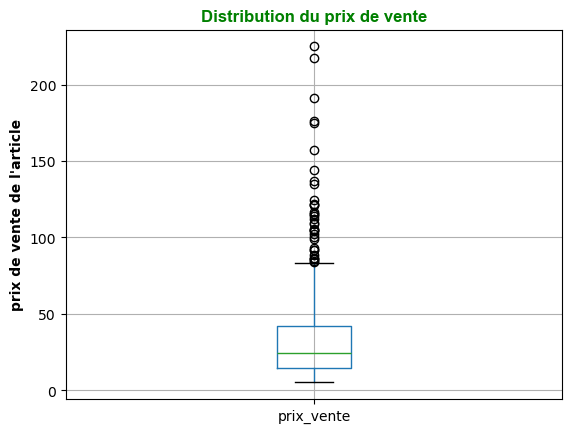

<Figure size 1200x600 with 0 Axes>

In [299]:
# Création d'une boite à moustache de la repartition des prix

df_merge_final.boxplot(column='prix_vente', vert= True)

plt.title("Distribution du prix de vente", color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("", fontweight="bold")
plt.ylabel("prix de vente de l'article", fontweight="bold")
plt.figure(figsize= (12,6))
plt.show()

In [300]:
# Distribution du prix selon que l'article est en stock ou pas en utilisant plotly express

fig = px.box(df_merge_final, x='stock_status', y='prix_vente',
             points='all',
             labels = {"prix_vente": "Prix de vente de l'article", "stock_status": "Statut du stock"},
             title="Distribution du prix de vente selon la dispobilité de l'article")
fig.show()





<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2 - Exploration par l'utilisation de méthodes statistiques</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.1 - Identification par le Z-index</h3>
</div>

In [303]:
# Calcule du prix moyen 

df_merge_final["prix_vente"].mean()


df_merge_final["prix_vente"].describe()

count    825.000000
mean      32.277758
std       26.603025
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: prix_vente, dtype: float64

In [304]:

# écart type du prix

df_merge_final["prix_vente"].std()


26.6030252393014

In [305]:
# Calcul du z-score

df_merge_final["z_score"] = (df_merge_final["prix_vente"] - df_merge_final["prix_vente"].mean()) / df_merge_final["prix_vente"].std()

df_vente = df_merge_final[["product_id",  "id_web", "sku", "stock_quantity", "stock_status", "purchase_price", "prix_vente", "augm_prix",  "total_sales", "product_type", "post_name", "post_modified", "post_date", "z_score"]]


df_vente.head()

,product_id,id_web,sku,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix,total_sales,product_type,post_name,post_modified,post_date,z_score
0,3847,15298,15298,16,instock,12.88,24.2,87.89,6.0,Vin,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2018-02-08 12:58:52,-0.303641
1,3849,15296,15296,10,instock,17.54,34.3,95.55,9.0,Vin,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2018-02-08 13:49:41,0.076016
2,3850,15300,15300,0,outofstock,10.64,20.8,95.49,0.0,Vin,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2018-02-08 14:08:36,-0.431446
3,4032,19814,19814,26,instock,6.92,14.1,103.76,12.0,Vin,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2018-02-09 14:01:05,-0.683297
4,4039,19815,19815,3,instock,23.77,46.0,93.52,3.0,Vin,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2018-02-12 09:04:37,0.515815


In [306]:
# Seuil prix dont le z-score est supérieur à 3

mask = df_vente["z_score"].abs() > 3


articles_atypiques = df_vente.loc[mask, :].sort_values(by = "z_score")


# Liste des produits avec des prix atypiques

articles_atypiques[["product_id", "purchase_price", "prix_vente", "augm_prix", "product_type", "post_name"]]

,product_id,purchase_price,prix_vente,augm_prix,product_type,post_name
652,5918,52.25,114.0,118.18,Whisky,wemyss-malts-single-cask-scotch-whisky-chai-ca...
711,6215,56.45,115.0,103.72,Vin,domaine-des-comtes-lafon-volnay-1er-cru-champa...
708,6212,59.42,115.0,93.54,Vin,domaine-des-comtes-lafon-volnay-1er-cru-santen...
703,6202,63.15,116.4,84.32,Vin,domaine-clerget-echezeaux-en-orveaux-2015
712,6216,60.02,121.0,101.60,Vin,domaine-des-comtes-lafon-volnay-1er-cru-champa...
709,6213,63.14,121.0,91.64,Vin,domaine-des-comtes-lafon-volnay-1er-cru-santen...
651,5917,54.24,122.0,124.93,Whisky,wemyss-malts-single-cask-scotch-whisky-choc-n-...
556,5612,66.41,124.8,87.92,Vin,domaine-weinbach-gewurztraminer-gc-furstentum-...
697,6126,80.33,135.0,68.06,Champagne,champagne-gosset-celebris-vintage-2007
411,4904,67.95,137.0,101.62,Vin,domaine-des-croix-corton-charlemagne-grand-cru...


Le seuil prix dont le z-score est supérieur à 3 est 114. Par conséquent tous les articles avec un prix de vente supérieur à 114 peuvent etre consiéré comme des articles avec des prix atypiques

In [308]:
print("Il y'a donc", df_vente.loc[df_vente["prix_vente"] > 114, "product_id"].count(), "articles avec un prix anormalement élevé, soit supérieur à 114 euros.")

print("Ces articles représentent",  round((df_vente.loc[df_vente["prix_vente"] > 114, "product_id"].count() / df_vente["product_id"].count()) * 100, 2), "% des articles du catalogue")


Il y'a donc 16 articles avec un prix anormalement élevé, soit supérieur à 114 euros.
Ces articles représentent 1.94 % des articles du catalogue


L'analyse des noms des articles avec des prix atypiques , c'est à dire anormalement élevé par rapport au niveau moyen de prix partatiqué dans le site, montre qu'il s'agit des produits haut de gamme. Par conséquent ce niveau de prix élevé est justifié. 

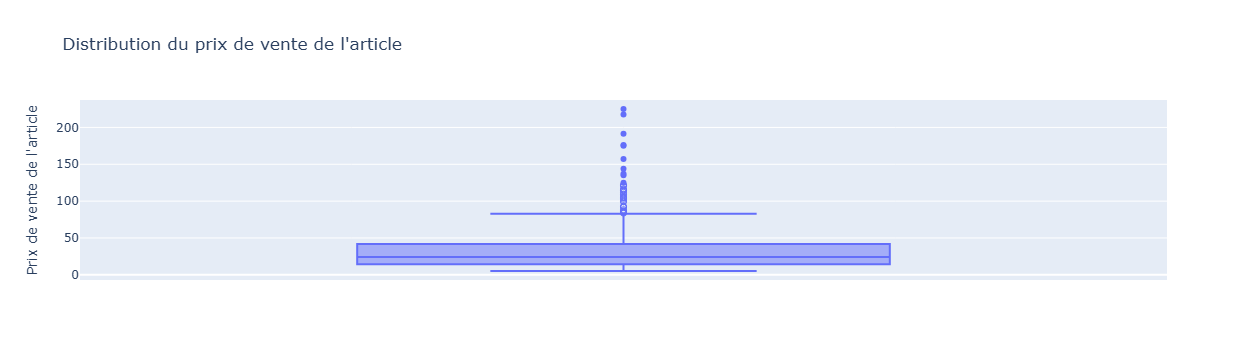

In [310]:
# Distribution du prix selon que l'article est en stock ou pas en utilisant plotly express

fig = px.box(df_vente, y='prix_vente',
             points='suspectedoutliers',
             labels = {"prix_vente": "Prix de vente de l'article", "stock_status": "Statut du stock"},
             title="Distribution du prix de vente de l'article")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.2 - Identification par l'intervalle interquartile</h3>
</div>

In [312]:
# Utilisation de la fonction "describe" de Pandas pour l'étude des mesures de dispersion

df_vente["prix_vente"].describe()

count    825.000000
mean      32.277758
std       26.603025
min        5.200000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: prix_vente, dtype: float64

In [313]:
# Définir le seuil pour les articles "outliers" en prix


 Définir le seuil pour les articles **outliers** en prix
On considére qu'un article est  un outlier si  son prix est en dehors de l'intervalle **Q1-1.5 * IQR ;  Q3 + 1.5 * IQR**.

Avec **Q1** le 1er quartile, **Q3** le 3e quartile et **IQR** l'intervalle interquartile.

soit  l'intervalle [14.6 - 1.5 * 27.4 ; 42 + 1.5 * 27.4]  ce qui équivaut à [-26.5 ; 83,1].

In [315]:
# Définition du nombre d'article outliers

df_outliers = df_vente.loc[(df_vente["prix_vente"] < -26.5) | (df_vente["prix_vente"] > 83.1), :]

# Proportion d'articles outliers de l'ensemble du catalogue

prop_outliers =  (df_outliers["product_id"].count() / df_vente["product_id"].count()) * 100

print("En tenant compte du prix, il y'a ", df_outliers["product_id"].count() ,"articles outliers. Soit", round(prop_outliers, 2),"% de l'ensemble des articles du catalogue")

En tenant compte du prix, il y'a  36 articles outliers. Soit 4.36 % de l'ensemble des articles du catalogue


In [316]:
df_outliers["prix_vente"].describe()

count     36.000000
mean     120.841667
std       36.254516
min       83.700000
25%       97.500000
50%      110.800000
75%      127.350000
max      225.000000
Name: prix_vente, dtype: float64

Pour cette 2e option les articles avec des prix supérieurs à 83 euros sont des produits atypiques.

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">4.2.3 - Ces outliers sont - ils justifiés ?</h3>
</div>

In [319]:
# DESCRIPTION DES ARTICLES ATYPIQUES ET NON ATYPIQUES 

articles_atypiques = df_vente.loc[df_vente["prix_vente"] > 114, "product_id"].to_list()

# Exclusion des articles avec des prix atypiques 

mask_2 = ~df_vente["product_id"].isin(articles_atypiques)

mask_3 = df_vente["product_id"].isin(articles_atypiques)



df_vente_non_atypique = df_vente.loc[mask_2, :]

df_vente_atypique = df_vente.loc[mask_3, :]


In [320]:
# Description des produits avec des prix non atypiques

df_vente_non_atypique[["purchase_price", "prix_vente", "augm_prix"]].describe()


,purchase_price,prix_vente,augm_prix
count,809.000000,809.000000,806.000000
mean,15.709543,29.958158,92.984504
std,11.251829,20.464106,12.532285
min,2.740000,5.200000,-83.670000
25%,7.420000,14.400000,87.900000
50%,12.480000,24.000000,93.515000
75%,21.380000,40.200000,99.550000
max,99.000000,114.000000,129.690000


In [321]:
# Description des produits avec des prix non atypiques

df_vente_atypique[["purchase_price", "prix_vente", "augm_prix"]].describe()

,purchase_price,prix_vente,augm_prix
count,16.000000,16.000000,16.000000
mean,79.185000,149.562500,92.632500
std,24.786075,36.827415,21.162024
min,54.240000,115.000000,63.270000
25%,62.360000,121.000000,80.255000
50%,68.515000,136.000000,92.590000
75%,88.125000,175.250000,102.145000
max,137.810000,225.000000,127.270000


In [322]:
# Nom exacte des articles avec des prix anormalement élevés

print(df_vente_atypique["post_name"].to_list())

['champagne-egly-ouriet-grand-cru-millesime-2008', 'cognac-frapin-vip-xo', 'cognac-frapin-chateau-de-fontpinot-1989-20-ans', nan, 'domaine-des-croix-corton-charlemagne-grand-cru-2016', 'david-duband-charmes-chambertin-grand-cru-2014', 'domaine-weinbach-gewurztraminer-gc-furstentum-sgn-2010', 'camille-giroud-clos-de-vougeot-2016', 'coteaux-champenois-egly-ouriet-ambonnay-rouge-2016', 'wemyss-malts-single-cask-scotch-whisky-choc-n-nut-pretzel-2001', 'champagne-gosset-celebris-vintage-2007', 'domaine-clerget-echezeaux-en-orveaux-2015', 'domaine-des-comtes-lafon-volnay-1er-cru-santenots-du-milieu-2015', 'domaine-des-comtes-lafon-volnay-1er-cru-santenots-du-milieu-2016', 'domaine-des-comtes-lafon-volnay-1er-cru-champans-2014', 'domaine-des-comtes-lafon-volnay-1er-cru-champans-2016']


Les prix tres élevés des articles outliers peut se justifier par le fait qu'il s'agit des produits haut de gamme qui ont généralement des prix élevés par rapport aux articles ordinaires. Comparé aux autres produits , les produits qualifiés d'outliers ont un prix d'acquisition tres élevé à la base. Le prix median des produits outliers est de 68 euros contre 12 euros pour les autres produits. De plus l'analyse du nom de ces articles avec des prix atypiques montre qu'il s'agit effectivement des articles haut de gamme, généralement vendu à des prix élevés. 

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univariée du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivariée  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.1 - Analyse des ventes en CA</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.1.1 - Calcul du chiffre d'affaires du site web</h4>
</div>

In [343]:
df_vente.head()

,product_id,id_web,sku,stock_quantity,stock_status,purchase_price,prix_vente,augm_prix,total_sales,product_type,post_name,post_modified,post_date,z_score
0,3847,15298,15298,16,instock,12.88,24.2,87.89,6.0,Vin,pierre-jean-villa-saint-joseph-preface-2018,2019-12-30 09:30:29,2018-02-08 12:58:52,-0.303641
1,3849,15296,15296,10,instock,17.54,34.3,95.55,9.0,Vin,pierre-jean-villa-saint-joseph-tilde-2017,2019-12-21 09:00:17,2018-02-08 13:49:41,0.076016
2,3850,15300,15300,0,outofstock,10.64,20.8,95.49,0.0,Vin,pierre-jean-villa-croze-hermitage-accroche-coe...,2020-06-26 18:15:03,2018-02-08 14:08:36,-0.431446
3,4032,19814,19814,26,instock,6.92,14.1,103.76,12.0,Vin,pierre-jean-villa-igp-gamine-2018,2020-01-04 16:36:01,2018-02-09 14:01:05,-0.683297
4,4039,19815,19815,3,instock,23.77,46.0,93.52,3.0,Vin,pierre-jean-villa-cote-rotie-carmina-2017,2020-01-04 16:36:10,2018-02-12 09:04:37,0.515815


In [345]:
# Calcul du chiffre d'affaire par article

df_article_ca = df_vente.copy()

df_article_ca["ca_par_article"] = df_article_ca["total_sales"] * df_article_ca["prix_vente"]

# Calcul du CA  du site web

print("le chiffre d'affaire du site web est : ", df_article_ca["ca_par_article"].sum())


le chiffre d'affaire du site web est :  148714.1


In [347]:
# Chiffre d'affaires par produit

df_produit = df_article_ca.groupby("product_type")["ca_par_article"].sum().reset_index()
df_produit["chiffre d'affaires"] = df_produit["ca_par_article"]
df_produit = df_produit[["product_type",	"chiffre d'affaires"]]
df_produit

,product_type,chiffre d'affaires
0,Autre,175.0
1,Champagne,16173.6
2,Cognac,3170.2
3,Gin,504.0
4,Huile d'olive,497.7
5,Vin,125307.0
6,Whisky,2886.6


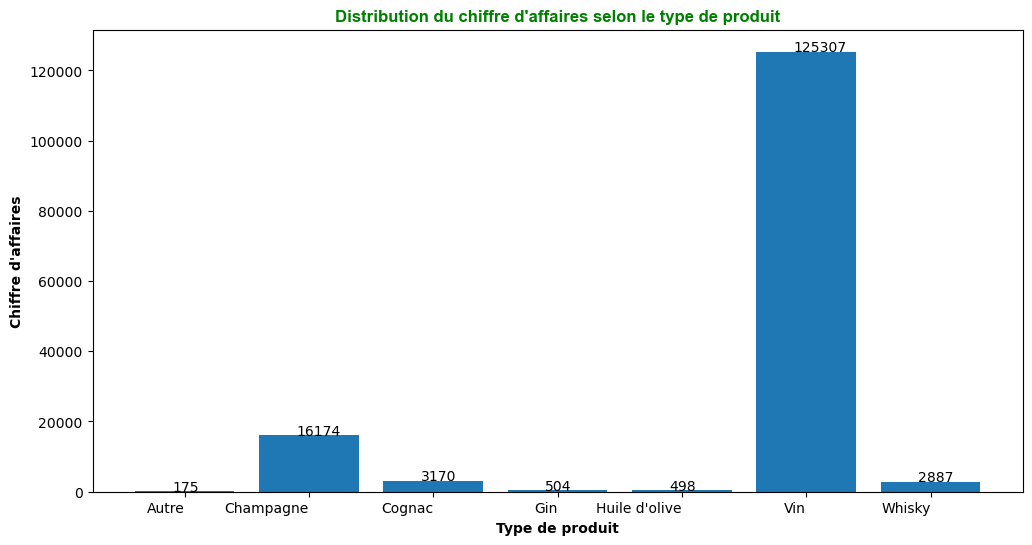

In [349]:
# Diagramme à bar du chiffre d'affaire par type de produit

plt.figure(figsize=(12,6))
plt.bar(height=df_produit["chiffre d'affaires"], x=df_produit["product_type"])

plt.title("Distribution du chiffre d'affaires selon le type de produit",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Type de produit", fontweight ="bold")
plt.ylabel("Chiffre d'affaires", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque type de produit

val_niv = df_produit["chiffre d'affaires"].tolist()
for i in range(7):
    plt.text(i-0.1, val_niv[i]+1, round(val_niv[i]))

plt.show()

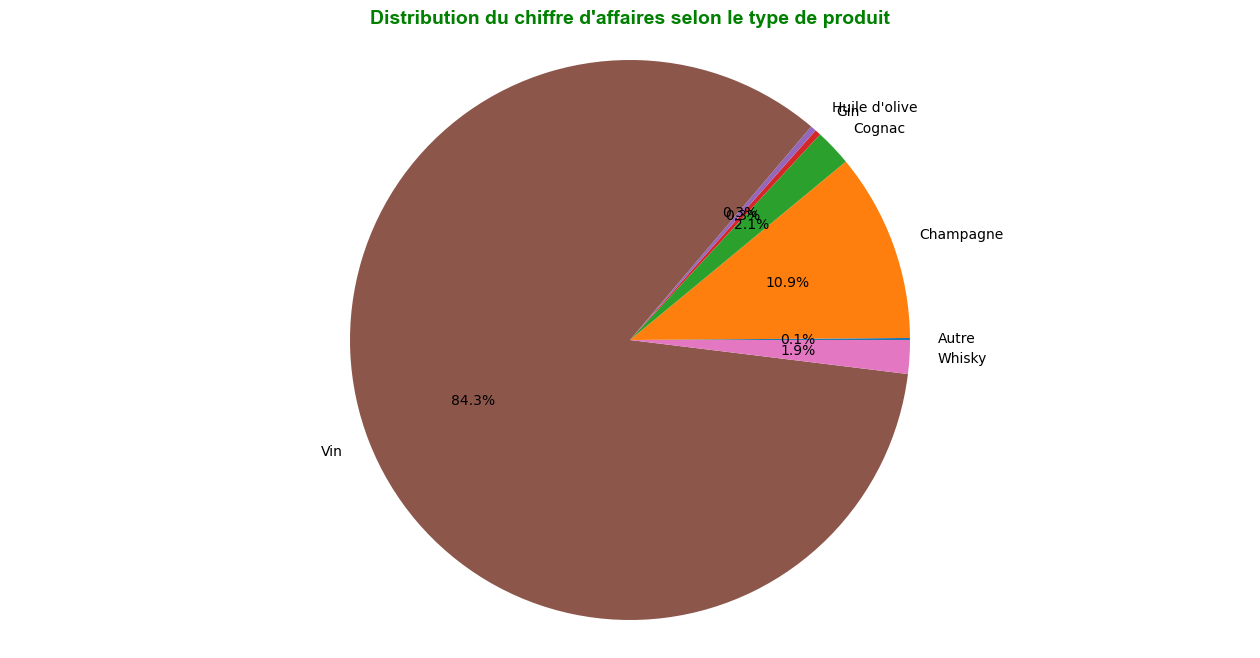

In [351]:


plt.figure(figsize=(16, 8))
plt.pie(x=df_produit["chiffre d'affaires"], labels=df_produit["product_type"], autopct='%.1f%%')
plt.title("Distribution du chiffre d'affaires selon le type de produit", color="green", fontweight="bold", fontname="Arial", fontsize=14)
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle
plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.1.2 - Meilleurs articles selon le chiffre d'affaire</h4>
</div>

In [356]:
# Articles en meilleures vente

df_article_ca = df_article_ca.sort_values(by = "ca_par_article", ascending=False).reset_index()

# Affichage des 20 1er articles selon le chiffre d'affaire 

df_article_ca[["product_id", "id_web", "product_type", "stock_quantity", "prix_vente", "total_sales", "ca_par_article"]].head(20)


,product_id,id_web,product_type,stock_quantity,prix_vente,total_sales,ca_par_article
0,4150,1366,Champagne,123,59.0,61.0,3599.0
1,4352,15940,Champagne,0,225.0,11.0,2475.0
2,5892,14983,Champagne,98,191.3,6.0,1147.8
3,4353,12587,Champagne,127,79.5,14.0,1113.0
4,4726,14950,Vin,0,12.7,72.0,914.4
5,5826,15325,Vin,34,41.2,20.0,824.0
6,6212,13996,Vin,16,115.0,7.0,805.0
7,5026,13913,Champagne,101,86.8,9.0,781.2
8,5008,11602,Vin,12,105.0,7.0,735.0
9,5067,15346,Vin,3,59.9,12.0,718.8


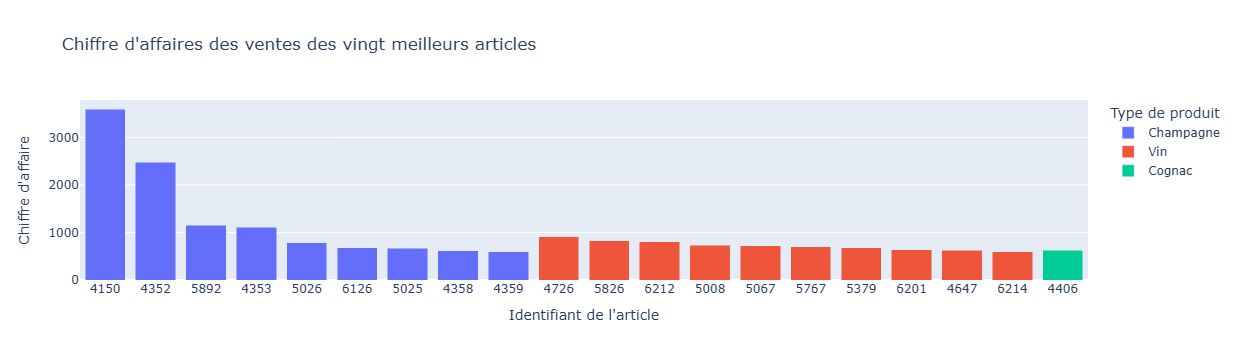

In [358]:
# Graphique à barre des 20 premiers articles avec plotly express


df_best_articles = df_article_ca.head(20).copy()

df_best_articles["product_id_char"] = df_best_articles["product_id"].astype(str)


fig = px.bar(df_best_articles,
             x="product_id_char",
             y="ca_par_article",
             color='product_type',
             barmode='stack',
             labels = {"product_id_char": "Identifiant de l'article", "ca_par_article": "Chiffre d'affaire", "product_type":"Type de produit"},
             title="Chiffre d'affaires des ventes des vingt meilleurs articles")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.1.3 - Calcul du 20/80 selon chiffre d'affaires</h4>
</div>

In [378]:
# Suppression des articles avec un chiffre d'affaires non renseigné

mask = ~df_article_ca["ca_par_article"].isnull()

df_article_ca_Notnull2 = df_article_ca.loc[mask, :]

df_article_ca_Notnull = df_article_ca_Notnull2.copy()

# Calcul de la part du CA en % de chaque  article
df_article_ca_Notnull["part_CA"] = round(((df_article_ca_Notnull["ca_par_article"] / df_article_ca_Notnull["ca_par_article"].sum())  * 100), 3)


In [380]:
# Calcul de la part du CA en % cumulée de chaque article

df_article_ca_Notnull["part_CA_cumule"] = df_article_ca_Notnull["part_CA"].cumsum()


In [382]:
# Calcul du nombre d'article représentant 80% du CA

article_CA_sup_80 = df_article_ca_Notnull.loc[df_article_ca_Notnull["part_CA_cumule"] < 81, : ]

print("Le nombre d'article représentant 80% du chiffre d'affaire est de :", article_CA_sup_80["product_id"].count(), "sur un total de", df_article_ca_Notnull["product_id"].count(), "articles vendus")

Le nombre d'article représentant 80% du chiffre d'affaire est de : 437 sur un total de 714 articles vendus


In [246]:
# la proportion que représente ce groupe d'articles dans le catalogue entier du site web


prop = round((article_CA_sup_80["ca_par_article"].sum() / df_article_ca_Notnull["ca_par_article"].sum()) * 100, 2)

print("Ce groupe d'article représente", prop, "% du CA des ventes du site web")

Ce groupe d'article représente 80.92 % du CA des ventes du site web


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.2 - Analyse des ventes en quantité</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.2.1 - Meilleurs articles en termes de quantités vendues</h4>
</div>

In [275]:
# Tri dans l'ordre décroissant des quantités vendues

df_article_qte = df_article_ca_Notnull.copy()

df_article_qte = df_article_qte.sort_values(by = "total_sales", ascending=False).reset_index()
df_article_qte = df_article_qte[["product_id", "id_web", "sku", "product_type", "stock_quantity", "stock_status", "purchase_price", "prix_vente", "total_sales", "post_modified", "post_date", "z_score", "ca_par_article", "part_CA", "part_CA_cumule"]].copy()

# Affichage des 20 premiers articles en quantité

df_article_qte.head(20)

,product_id,id_web,sku,product_type,stock_quantity,stock_status,purchase_price,prix_vente,total_sales,post_modified,post_date,z_score,ca_par_article,part_CA,part_CA_cumule
0,4726,14950,14950,Vin,0,outofstock,6.82,12.7,72.0,2020-05-06 11:35:01,2018-04-18 11:53:51,-0.735922,914.4,0.615,6.219
1,4150,1366,1366,Champagne,123,instock,35.45,59.0,61.0,2020-08-26 18:05:02,2018-02-13 13:45:31,1.004481,3599.0,2.420,2.420
2,5379,14561,14561,Vin,33,instock,5.68,11.1,61.0,2020-07-11 14:00:03,2018-09-01 15:34:55,-0.796066,677.1,0.455,9.742
3,4867,16148,16148,Vin,121,instock,4.86,9.9,36.0,2020-08-27 09:30:15,2018-05-03 13:20:05,-0.841173,356.4,0.240,25.998
4,4203,15415,15415,Vin,74,instock,5.01,9.9,27.0,2020-07-11 16:45:03,2018-02-15 14:33:42,-0.841173,267.3,0.180,42.425
5,4275,14864,14864,Vin,62,instock,7.78,14.9,24.0,2020-08-22 14:35:02,2018-02-27 13:33:54,-0.653225,357.6,0.240,24.798
6,4647,16525,16525,Vin,45,instock,14.14,28.5,22.0,2020-07-31 09:31:39,2018-04-17 09:28:58,-0.142005,627.0,0.422,11.918
7,5826,15325,15325,Vin,34,instock,21.71,41.2,20.0,2020-05-21 14:00:02,2019-03-27 17:59:49,0.335385,824.0,0.554,6.773
8,6129,14570,14570,Vin,68,instock,2.74,5.2,20.0,2020-08-26 15:55:02,2019-06-28 18:01:06,-1.017845,104.0,0.070,95.365
9,4220,15758,15758,Vin,48,instock,5.75,11.6,18.0,2020-08-27 11:45:02,2018-02-16 10:54:27,-0.777271,208.8,0.140,59.489


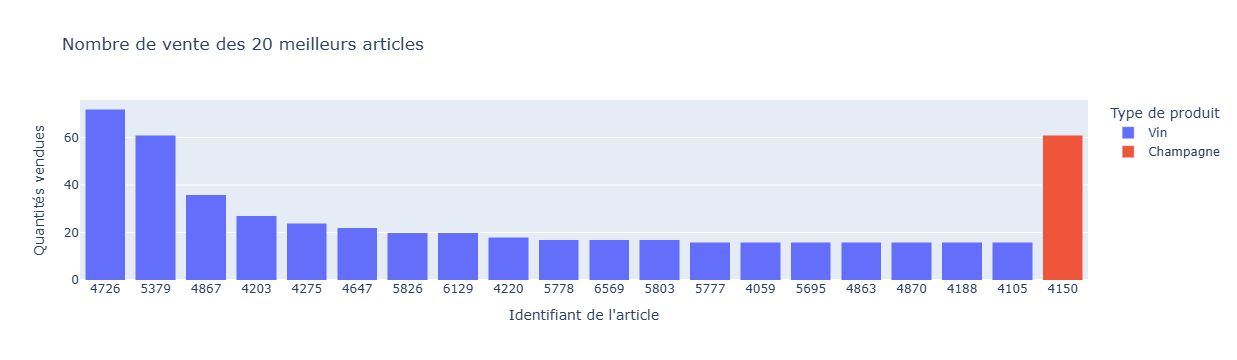

In [277]:
# Graphique en barre des 20 premiers articles avec plotly express

df_best_articles = df_article_qte.head(20).copy()

df_best_articles["product_id_char"] = df_best_articles["product_id"].astype(str)


fig = px.bar(df_best_articles,
             x="product_id_char",
             y="total_sales",
             color='product_type',
             barmode='stack',
             labels = {"product_id_char": "Identifiant de l'article", "total_sales": "Quantités vendues", "product_type":"Type de produit"},
             title="Nombre de vente des 20 meilleurs articles")
fig.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.2.2 - Calcul du 20/80 en chiffre d'affaire</h4>
</div>

In [279]:
# Calcul de la part en quantité (en % ) de la ligne dans le dataset

df_article_qte["part_quantite"] = round(((df_article_qte["total_sales"] / df_article_qte["total_sales"].sum())  * 100), 2)


In [281]:

# Somme cumulée de la part de la quantité d'article vendue

df_article_qte["part_qte_cumule"] = df_article_qte["part_quantite"].cumsum()


In [283]:

# Calcul du nombre d'article représentant 80% des ventes en quantité

article_ventes_sup_80 = df_article_qte.loc[df_article_qte["part_qte_cumule"] < 81, : ]

print("Le nombre d'article représentant 80 % des ventes est :", article_ventes_sup_80["product_id"].count())




Le nombre d'article représentant 80 % des ventes est : 434


In [285]:

# la proportion que représente ce groupe d'articles dans le catalogue entier du site web

prop = round((article_ventes_sup_80["total_sales"].sum() / df_article_qte["total_sales"].sum()) * 100, 2)

print("Ce groupe d'article représente", prop, "% du CA des ventes du site web")

Ce groupe d'article représente 80.56 % du CA des ventes du site web


In [287]:
# Quantités vendues par type de produits
df_article_qte2 = df_article_qte.groupby("product_type")["total_sales"].sum().reset_index(name = "Quantités vendues")
df_article_qte2

,product_type,Quantités vendues
0,Autre,7.0
1,Champagne,224.0
2,Cognac,35.0
3,Gin,14.0
4,Huile d'olive,22.0
5,Vin,5566.0
6,Whisky,48.0


In [289]:
# Prix moyen par type de produits

df_article_qte3 = df_article_qte.groupby("product_type")["prix_vente"].mean().reset_index(name = "prix_vente_moyen")
df_article_qte3

,product_type,prix_vente_moyen
0,Autre,25.000000
1,Champagne,69.626786
2,Cognac,97.500000
3,Gin,36.000000
4,Huile d'olive,24.933333
5,Vin,29.281307
6,Whisky,65.557143


In [291]:
# Prix minimum par type de produit

df_article_qte4 = df_article_qte.groupby("product_type")["prix_vente"].min().reset_index(name = "prix_vente_minimum")
df_article_qte4

,product_type,prix_vente_minimum
0,Autre,25.00
1,Champagne,12.65
2,Cognac,44.00
3,Gin,36.00
4,Huile d'olive,13.10
5,Vin,5.20
6,Whisky,27.50


In [293]:
# Prix de vente maximum  par type de produit

df_article_qte5 = df_article_qte.groupby("product_type")["prix_vente"].max().reset_index(name = "prix_vente_maximum")
df_article_qte5

,product_type,prix_vente_maximum
0,Autre,25.0
1,Champagne,225.0
2,Cognac,176.0
3,Gin,36.0
4,Huile d'olive,42.2
5,Vin,217.5
6,Whisky,122.0


In [295]:
# Tableau récapitulatif du chiffre d'affaires et des ventes par type de produits

df_1 = pd.merge(df_article_qte2, df_article_qte3, on = "product_type", how="inner")
df_recap = pd.merge(df_1, df_produit, on = "product_type", how="inner")

df_recap

,product_type,Quantités vendues,prix_vente_moyen,chiffre d'affaires
0,Autre,7.0,25.000000,175.0
1,Champagne,224.0,69.626786,16173.6
2,Cognac,35.0,97.500000,3170.2
3,Gin,14.0,36.000000,504.0
4,Huile d'olive,22.0,24.933333,497.7
5,Vin,5566.0,29.281307,125307.0
6,Whisky,48.0,65.557143,2886.6


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.3 - Analyse des stocks</h3>
</div>




<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.3.1 - Calcul du nombre de mois de stock</h4>
</div>

In [299]:
df_article_qte["stock_quantity"].describe()

count    714.000000
mean      23.445378
std       22.219243
min        0.000000
25%        9.000000
50%       20.000000
75%       30.000000
max      145.000000
Name: stock_quantity, dtype: float64

In [301]:
# Création de la colonne rotation des stocks

df_article_qte["rotation_stock"] = round(df_article_qte["total_sales"] / df_article_qte["stock_quantity"], 2)

df_article_qte["rotation_stock_2"] = round(df_article_qte["stock_quantity"] / df_article_qte["total_sales"], 2)



# Replacement des inf par 0 

df_article_qte.loc[df_article_qte["rotation_stock"] == np.inf, "rotation_stock"] = 0.0
df_article_qte.loc[df_article_qte["rotation_stock_2"] == np.inf, "rotation_stock_2"] = 0.0


# Effectuer le tri dans l'ordre décroissant du nombre de mois de stock

df_article_qte = df_article_qte.sort_values(by = "rotation_stock_2", ascending=False).reset_index()

df_article_qte = df_article_qte[["product_id", "id_web", "sku", "product_type", "stock_quantity", "stock_status", "purchase_price", "prix_vente", "total_sales", "post_modified", "post_date", "z_score", "ca_par_article", "part_CA", "part_CA_cumule", "rotation_stock", "rotation_stock_2"]].copy()



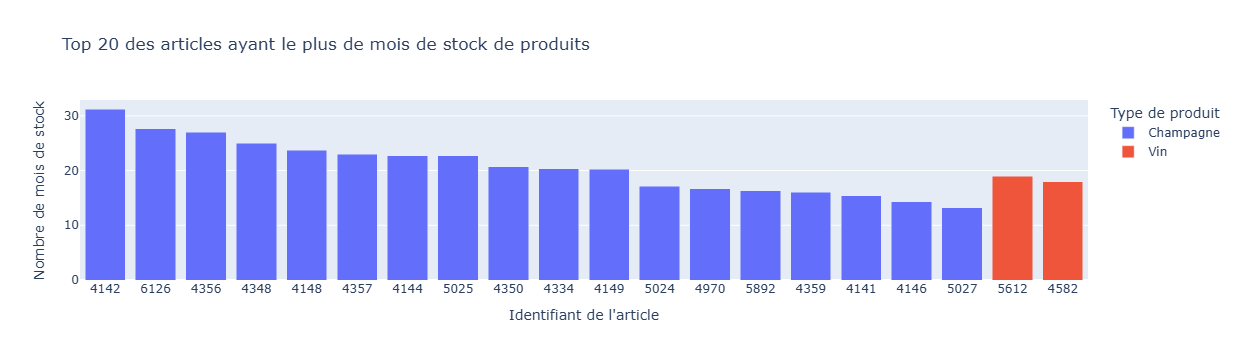

In [303]:
# Graphique en barre du top 20 des produits qui ont le plus de mois de stock

mask = ~df_article_qte["rotation_stock_2"].isnull()
df_top20_mois_stock = df_article_qte.loc[mask, :].head(20).copy()


df_top20_mois_stock["product_id_char"] = df_top20_mois_stock["product_id"].astype(str)


fig = px.bar(df_top20_mois_stock,
             x="product_id_char",
             y="rotation_stock_2",
             color='product_type',
             barmode='stack',
             labels = {"product_id_char": "Identifiant de l'article", "rotation_stock_2": "Nombre de mois de stock", "product_type":"Type de produit"},
             title="Top 20 des articles ayant le plus de mois de stock de produits")
fig.show()


In [305]:

# Tableau des quantités et du nombre de mois de stocks

qte_stocks = df_article_qte.groupby("product_type")["stock_quantity"].sum().reset_index(name = "quantités en stock")
qte_stocks



mois_stocks = df_article_qte.groupby("product_type")["total_sales"].sum().reset_index(name = "quantités vendus")

mois_stocks["nbre de mois de stock"] = qte_stocks["quantités en stock"] / mois_stocks["quantités vendus"]


df_stocks = pd.merge(qte_stocks,  mois_stocks, on = "product_type", how="inner")
df_stocks

,product_type,quantités en stock,quantités vendus,nbre de mois de stock
0,Autre,23,7.0,3.285714
1,Champagne,2894,224.0,12.919643
2,Cognac,99,35.0,2.828571
3,Gin,11,14.0,0.785714
4,Huile d'olive,158,22.0,7.181818
5,Vin,13470,5566.0,2.420050
6,Whisky,85,48.0,1.770833


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.3.2 - Valorisation des stocks en euros</h4>
</div>

In [307]:

# Création de la colonne Valorisation des stocks en euros

df_article_qte["valorisation_stocks_euros"] = df_article_qte["stock_quantity"] * df_article_qte["prix_vente"]

# Calculer la somme de la colonne "Valorisation_stock_euros"

print("La valeur totale des stocks est de :", round(df_article_qte["valorisation_stocks_euros"].sum()))

La valeur totale des stocks est de : 494638


In [309]:

df_stocks = df_article_qte.groupby("product_type")["valorisation_stocks_euros"].sum().reset_index(name = "valeur des stocks")
df_stocks

,product_type,valeur des stocks
0,Autre,575.00
1,Champagne,192482.95
2,Cognac,9761.20
3,Gin,396.00
4,Huile d'olive,3131.70
5,Vin,282258.15
6,Whisky,6032.90


<div style="border: 1px solid RGB(51,165,182);" >
<h4 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.3.3 - Valorisation du nombre de produits en stock</h4>
</div>

La quantité de produits en stock est de : 16740


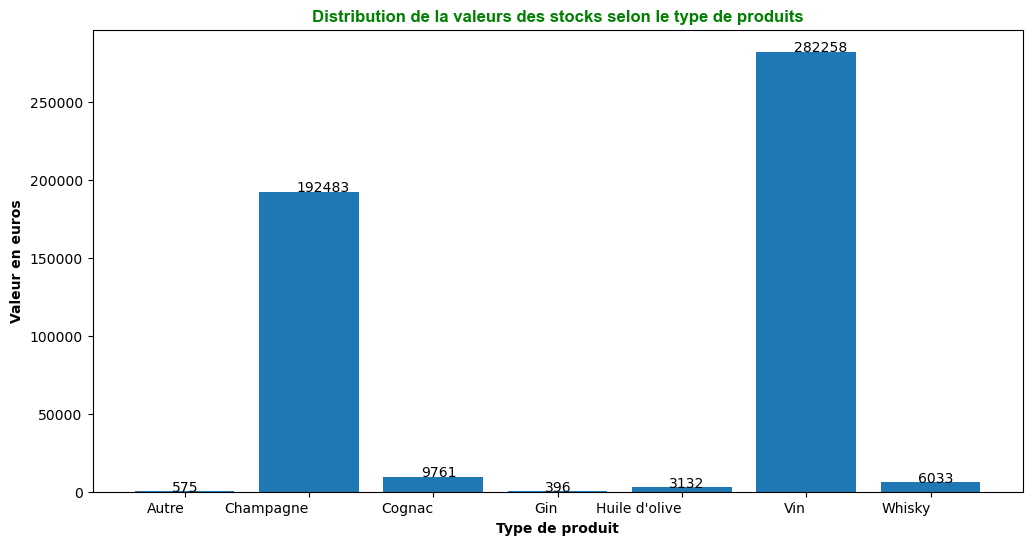

In [311]:
# Calculer la somme de la colonne stock quantity

print("La quantité de produits en stock est de :", round(df_article_qte["stock_quantity"].sum()))


# Diagramme à barre de lavaleur des stocks selon le type de produit



plt.figure(figsize=(12,6))
plt.bar(height=df_stocks["valeur des stocks"], x=df_stocks["product_type"])

plt.title("Distribution de la valeurs des stocks selon le type de produits",
          color="green", fontweight="bold", fontname="Arial", fontsize=12)
plt.xlabel("Type de produit", fontweight ="bold")
plt.ylabel("Valeur en euros", fontweight ="bold")
plt.xticks(rotation=0, ha='right')  # ha='right' = alignement à droite


# Afficher les valeurs associées à chaque type de produit

val_niv = df_stocks["valeur des stocks"].tolist()
for i in range(7):
    plt.text(i-0.1, val_niv[i]+1, round(val_niv[i]))

plt.show()

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.4 - Analyse du taux de marge</h3>
</div>

In [313]:
# Calcul prix HT. on considere la TVA 0 20%


df_article_qte["prix_vente_HT"] = df_article_qte["prix_vente"]  / 1.2


# Calcul du prix d'achat HT 

df_article_qte["prix_achat_HT"] = df_article_qte["purchase_price"]  / 1.2


# Calcul du taux de marge

df_article_qte["taux_de_marge"] = round(((df_article_qte["prix_vente_HT"] -  df_article_qte["prix_achat_HT"]) / df_article_qte["prix_achat_HT"]) * 100, 2)



In [327]:
# L'article ayant le taux de marge le plus faible 
df_article_qte.loc[df_article_qte["taux_de_marge"] == df_article_qte["taux_de_marge"].min(), ["product_id", "product_type", "stock_quantity", "purchase_price",	"prix_vente",	"total_sales",	"ca_par_article", "rotation_stock_2", "taux_de_marge"]]


,product_id,product_type,stock_quantity,purchase_price,prix_vente,total_sales,ca_par_article,rotation_stock_2,taux_de_marge
666,4355,Champagne,97,77.48,12.65,0.0,0.0,0.0,-83.67


In [329]:
# L'article ayant le taux de marge le plus élevé
df_article_qte.loc[df_article_qte["taux_de_marge"] == df_article_qte["taux_de_marge"].max(), ["product_id", "product_type", "stock_quantity", "purchase_price",	"prix_vente",	"total_sales",	"ca_par_article", "rotation_stock_2", "taux_de_marge"]]


,product_id,product_type,stock_quantity,purchase_price,prix_vente,total_sales,ca_par_article,rotation_stock_2,taux_de_marge
533,4401,Cognac,5,27.21,62.5,3.0,187.5,1.67,129.69
638,5916,Whisky,1,40.49,93.0,1.0,93.0,1.00,129.69


In [985]:


# Afficher le prix minimum de la colonne "taux_marge"/ taux_de_marge min et max 

df_article_qte.loc[df_article_qte["prix_vente_HT"] == df_article_qte["prix_vente_HT"].min(), ["prix_vente_HT", "taux_de_marge"]]

# Afficher le prix maximum de la colonne "taux_marge"

df_article_qte.loc[df_article_qte["prix_vente_HT"] == df_article_qte["prix_vente_HT"].max(), ["prix_vente_HT", "taux_de_marge"]]


,prix_vente_HT,taux_de_marge
675,187.5,63.27


In [1]:
df_article_qte

NameError: name 'df_article_qte' is not defined

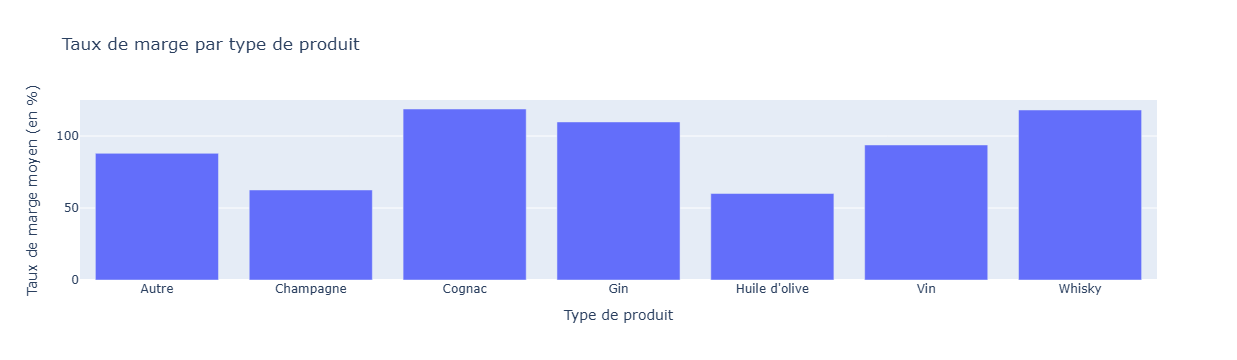

In [987]:
# Création d'un dataframe avec le taux de marge moyen par type de produit

data_type_produit = df_article_qte.groupby("product_type")["taux_de_marge"].mean().reset_index(name="taux_marge_moyen")

# Affichage dans un graphique du taux de marge par type de produit


fig = px.bar(data_type_produit,
             x="product_type",
             y="taux_marge_moyen",
             barmode='stack',
             labels = {"product_type": "Type de produit", "taux_marge_moyen": "Taux de marge moyen (en %)"},
             title="Taux de marge par type de produit")
fig.show()


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.5 - Analyse des corrélations entre les variables stock, sales et price</h3>
</div>

In [989]:
df_article_qte

,product_id,id_web,sku,product_type,stock_quantity,stock_status,purchase_price,prix_vente,total_sales,post_modified,post_date,z_score,ca_par_article,part_CA,part_CA_cumule,rotation_stock,rotation_stock_2,valorisation_stocks_euros,prix_vente_HT,prix_achat_HT,taux_de_marge
0,4142,11641,11641,Champagne,125,instock,32.15,53.0,4.0,2020-08-20 09:30:03,2018-02-13 13:08:44,0.778943,212.0,0.143,57.648,0.03,31.25,6625.0,44.166667,26.791667,64.85
1,6126,14923,14923,Champagne,138,instock,80.33,135.0,5.0,2020-08-27 11:45:02,2019-06-28 17:22:27,3.861299,675.0,0.454,10.196,0.04,27.60,18630.0,112.500000,66.941667,68.06
2,4356,12585,12585,Champagne,81,instock,31.00,51.6,3.0,2020-07-30 11:25:02,2018-03-02 10:51:14,0.726317,154.8,0.104,77.479,0.04,27.00,4179.6,43.000000,25.833333,66.45
3,4348,12586,12586,Champagne,125,instock,34.76,59.0,5.0,2020-08-12 14:00:02,2018-03-02 09:22:39,1.004481,295.0,0.198,35.821,0.04,25.00,7375.0,49.166667,28.966667,69.74
4,4148,1364,1364,Champagne,71,instock,21.88,37.5,3.0,2020-08-08 10:45:03,2018-02-13 13:36:44,0.196303,112.5,0.076,92.815,0.04,23.67,2662.5,31.250000,18.233333,71.39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
709,5544,14828,14828,Vin,0,outofstock,31.51,61.6,0.0,2020-03-27 09:30:10,2018-11-26 09:52:56,1.102215,0.0,0.000,100.007,NaN,NaN,0.0,51.333333,26.258333,95.49
710,4396,9636,9636,Whisky,0,outofstock,28.42,62.0,0.0,2020-08-19 17:45:03,2018-03-22 10:44:57,1.117250,0.0,0.000,100.007,NaN,NaN,0.0,51.666667,23.683333,118.16
711,4923,15928,15928,Vin,0,outofstock,3.65,7.0,0.0,2020-08-27 16:05:03,2018-05-17 11:53:08,-0.950184,0.0,0.000,100.007,NaN,NaN,0.0,5.833333,3.041667,91.78
712,5707,13557,13557,Vin,0,outofstock,5.69,10.8,0.0,2020-06-23 18:35:01,2019-01-31 14:13:47,-0.807343,0.0,0.000,100.007,NaN,NaN,0.0,9.000000,4.741667,89.81


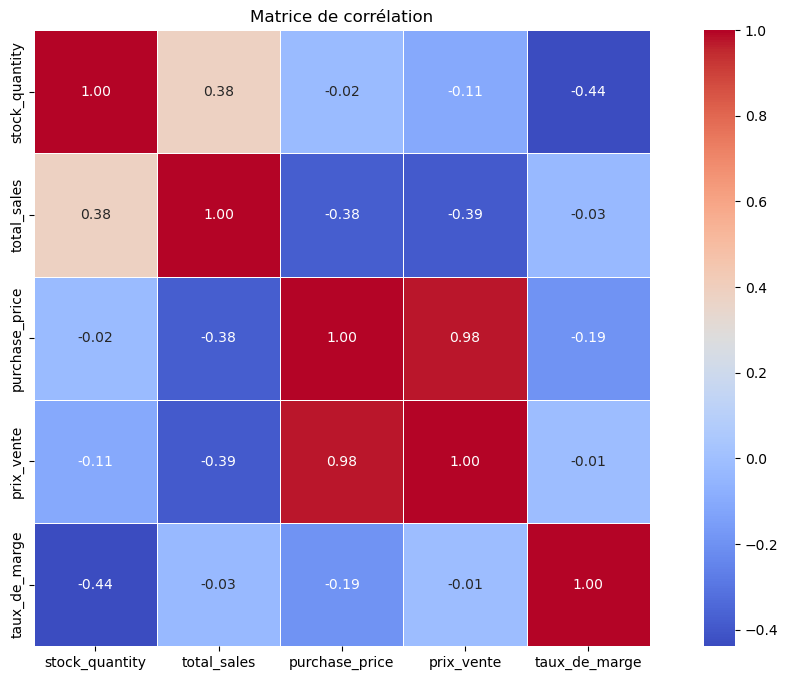

In [991]:
# importation de la librairie seaborn

import seaborn as sns

# Création d'une heatmap de corrélation avec les variables stock, sales et price

data = df_article_qte[["stock_quantity", "total_sales", "purchase_price", "prix_vente", "taux_de_marge"]]

corr_matrix = data.corr(numeric_only=True)

plt.figure(figsize=(14,8))
sns.heatmap(corr_matrix, 
            annot=True,          # Affiche les valeurs dans les cases
            fmt=".2f",           # Format des décimales
            cmap='coolwarm',     # Palette de couleurs
            linewidths=0.5,      # Lignes entre les cases
            square=True)         # Carrés parfaits
plt.title("Matrice de corrélation")
plt.show()

# Que peut on conclure des correlations ? 

1) On oberve une forte correlation positive entre le prix de vente et le prix d'achat. Plus le prix d'achat est élevé plus le produit est vendu a un prix élevé. 
2) Il n'existe quasiment pas de lien  entre le prix de vente et le taux de marge. Le site ne gagne pas particulierement de l'argent avec des articles haut de game qui ont des prix élevés.
3) On observe une correlationn négative entre le taux de marge et la quantité de produit en stock : Plus la quantité de stock d'un article est importante, moins le taux de marge appliqué à cette article est élevé. Ce qui est cohérent car un stock important d'un article peut traduire des difficultés d'écoulement. Par conséquent les prix prtatiqués pour ces articles sont relativement bas.
4) on observe une correlation négative entre le total des ventes et le prix de vente : plus les ventes sont élevés plus le prix de vente est faible. ce qui traduit le fait que les produits les plus vendus ont généralement les prix faibles et donc ce sont les produits ordinaires. 

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">5.6 - Mise à disposition de la nouvelle table sur un fichier Excel</h3>
</div>

In [520]:
# Mettre le dataset sur un fichier Excel

df_article_qte.to_excel("df_vente_bottleneck.xlsx", index=False)
